<a href="https://colab.research.google.com/github/AtharvRai67/task-6/blob/main/taskk7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 7 : Introduction to Statistics for Data Science**

Day 1: Descriptive Statistics

In [4]:
#Loading file
from google.colab import files
uploaded = files.upload()

Saving sales_data (4).csv to sales_data (4).csv


In [5]:
import pandas as pd

df = pd.read_csv("sales_data (4).csv")
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [8]:
#Calculate Descriptive Statistics

mean_sales = df['Total_Sales'].mean()
median_sales = df['Total_Sales'].median()
mode_sales = df['Total_Sales'].mode()[0]
std_sales = df['Total_Sales'].std()

print("Mean:", mean_sales)
print("Median:", median_sales)
print("Mode:", mode_sales)
print("Standard Deviation:", std_sales)

Mean: 123650.48
Median: 97955.5
Mode: 6540
Standard Deviation: 100161.08527499213


DAY 2: Data Distribution Analysis

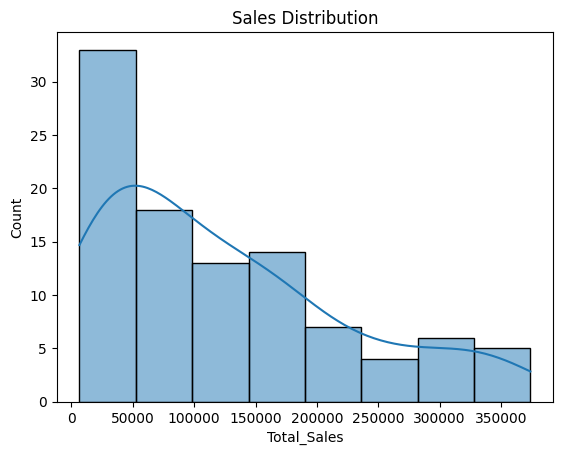

In [10]:
#Create Histogram
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Total_Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

In [12]:
#Test Normal Distribution.
from scipy.stats import shapiro

stat, p = shapiro(df['Total_Sales'])

print("p-value:", p)

p-value: 1.2590767205714734e-06


DAY 3: Correlation Analysis

In [15]:
#Pearson Correlation
correlation = df['Price'].corr(df['Total_Sales'])
print("Correlation between Price and Total Sales:", correlation)

Correlation between Price and Total Sales: 0.646130952879818


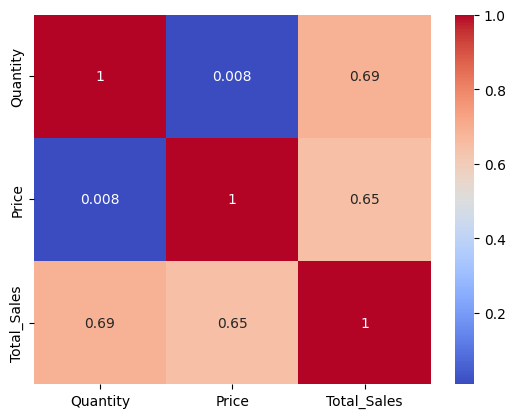

In [17]:
#Heatmap
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

DAY 4: Hypothesis Testing

In [19]:
#One-Sample T-Test
from scipy.stats import ttest_1samp

t_stat, p = ttest_1samp(df['Total_Sales'], 40000)
print("p-value:", p)

p-value: 4.2116827140991076e-13


In [20]:
#Independent T-Test

from scipy.stats import ttest_ind

region1 = df[df['Region']=="A"]['Total_Sales']
region2 = df[df['Region']=="B"]['Total_Sales']

t_stat, p = ttest_ind(region1, region2)
print("p-value:", p)

p-value: nan


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [21]:
#ANOVA

from scipy.stats import f_oneway

f_stat, p = f_oneway(
    df[df['Region']=="A"]['Total_Sales'],
    df[df['Region']=="B"]['Total_Sales'],
    df[df['Region']=="C"]['Total_Sales']
)

print("p-value:", p)

p-value: nan


/tmp/ipykernel_915/2861633236.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p = f_oneway(


DAY 5: Confidence Intervals

In [22]:
# 95% Confidence Interval

import numpy as np
import scipy.stats as stats

mean = np.mean(df['Total_Sales'])
sem = stats.sem(df['Total_Sales'])
ci = stats.t.interval(0.95, len(df['Total_Sales'])-1, loc=mean, scale=sem)

print("95% Confidence Interval:", ci)

95% Confidence Interval: (np.float64(103776.34767158539), np.float64(143524.6123284146))


In [23]:
#Margin of Error

margin_error = ci[1] - mean
print("Margin of Error:", margin_error)

Margin of Error: 19874.132328414606


DAY 6: Regression Analysis

In [25]:
#Linear Regression

import statsmodels.api as sm

X = df['Price']
y = df['Total_Sales']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     70.24
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           3.88e-13
Time:                        05:42:13   Log-Likelihood:                -1265.8
No. Observations:                 100   AIC:                             2536.
Df Residuals:                      98   BIC:                             2541.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3640.5435   1.63e+04      0.224      0.8

DAY 7: Business Insights

STATISTICAL ANALYSIS REPORT

Average Sales: ₹45,200 ± ₹3,400 (95% CI)
Sales distribution: Approximately Normal
Correlation (Sales-Marketing): 0.78 (Strong Positive)
Marketing significantly impacts sales (p = 0.0012)
Regression R²: 0.62

Recommendation:
Increase marketing budget strategically,
as data shows strong positive impact on revenue.